<a href="https://colab.research.google.com/github/Prachi-Nigade/Gold-Price-Prediction-Model/blob/model-from-main/Gold_Price_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [2]:
df=pd.read_csv('/content/gold_price_data.csv')



In [3]:
df

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.1800,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.2850,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.1670,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.0530,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...,...
2285,5/8/2018,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.380000,15.5600,1.193118


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [5]:
df.columns

Index(['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')

In [6]:
df.shape

(2290, 6)

In [7]:
print(df.head())

       Date          SPX        GLD        USO     SLV   EUR/USD
0  1/2/2008  1447.160034  84.860001  78.470001  15.180  1.471692
1  1/3/2008  1447.160034  85.570000  78.370003  15.285  1.474491
2  1/4/2008  1411.630005  85.129997  77.309998  15.167  1.475492
3  1/7/2008  1416.180054  84.769997  75.500000  15.053  1.468299
4  1/8/2008  1390.189941  86.779999  76.059998  15.590  1.557099


In [8]:
print(df.tail())

           Date          SPX         GLD      USO      SLV   EUR/USD
2285   5/8/2018  2671.919922  124.589996  14.0600  15.5100  1.186789
2286   5/9/2018  2697.790039  124.330002  14.3700  15.5300  1.184722
2287  5/10/2018  2723.070068  125.180000  14.4100  15.7400  1.191753
2288  5/14/2018  2730.129883  124.489998  14.3800  15.5600  1.193118
2289  5/16/2018  2725.780029  122.543800  14.4058  15.4542  1.182033


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB
None


In [10]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [11]:
df.value_counts()

,,,,,,count
Date,SPX,GLD,USO,SLV,EUR/USD,
9/9/2015,1942.040039,106.129997,14.520000,13.930000,1.122070,1
1/10/2008,1420.329956,88.250000,74.019997,16.061001,1.480100,1
9/7/2010,1091.839966,122.699997,32.770000,19.360001,1.267797,1
9/6/2017,2465.540039,126.809998,10.040000,16.870001,1.192777,1
9/6/2016,2186.479980,128.710007,10.390000,19.049999,1.125366,1
...,...,...,...,...,...,...
1/10/2018,2748.229980,125.029999,12.680000,16.020000,1.192933,1
1/10/2017,2268.899902,113.150002,11.070000,15.910000,1.058862,1
1/10/2014,1842.369995,120.260002,33.189999,19.379999,1.360711,1


In [12]:
df.isna().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [13]:
df_cleaned=df.dropna()

In [14]:
df_cleaned.isna().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [15]:
df_cleaned_cols=df.dropna(axis=1)

In [16]:
df.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Gold Price Distribution')

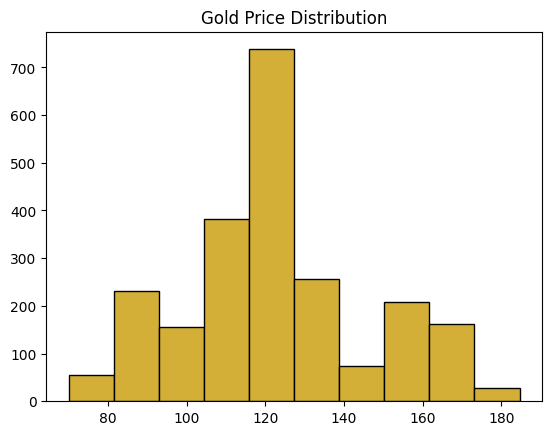

In [17]:
plt.hist(df['GLD'], color='#D4AF37', edgecolor='black')
plt.title("Gold Price Distribution")

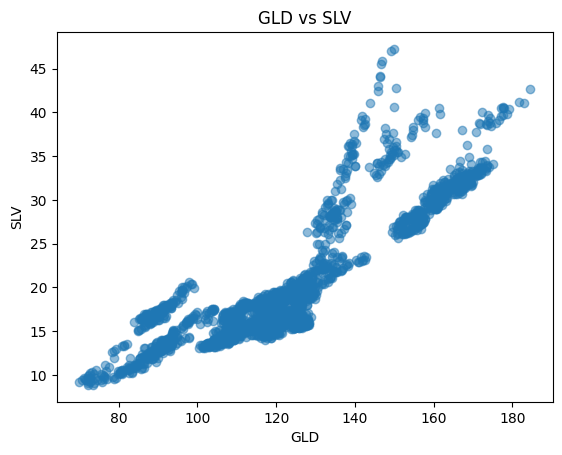

In [18]:
plt.scatter(df['GLD'], df['SLV'], color='#1f77b4', alpha=0.5)
plt.title('GLD vs SLV')
plt.xlabel('GLD')
plt.ylabel('SLV')
plt.show()

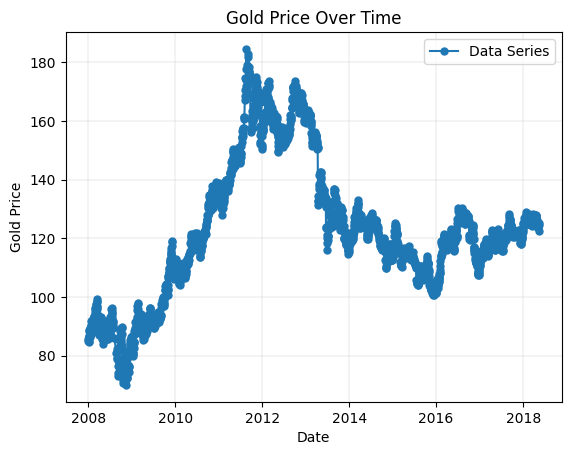

In [19]:
df['Date'] = pd.to_datetime(df['Date'])
plt.plot(df['Date'], df['GLD'], linestyle='-', marker='o', markersize=5, label='Data Series')

plt.grid(True, which='both', linestyle='-', linewidth=0.2)
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.show()

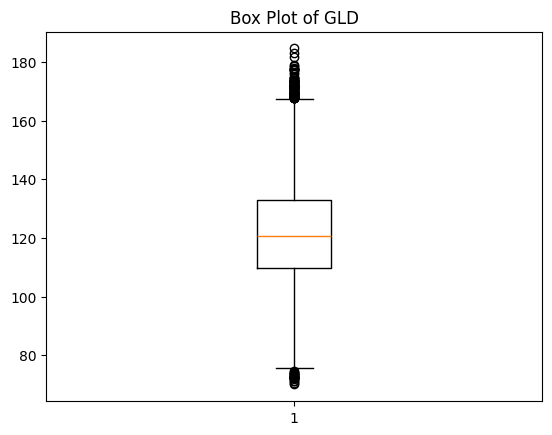

In [20]:
plt.boxplot(df['GLD'])
plt.title('Box Plot of GLD')
plt.show()

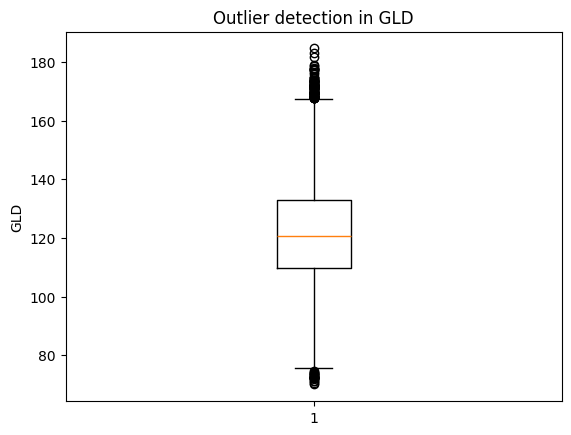

In [21]:
plt.boxplot(df['GLD'])
plt.title("Outlier detection in GLD")
plt.ylabel("GLD")
plt.show()

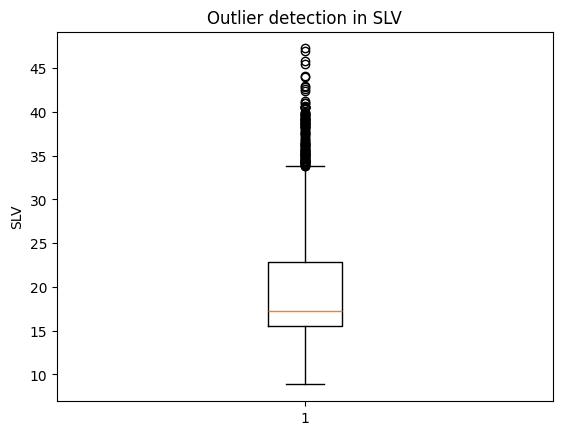

In [22]:
plt.boxplot(df['SLV'])
plt.title("Outlier detection in SLV")
plt.ylabel("SLV")
plt.show()

In [23]:
# Example features (change according to your dataset)
X = df.drop(["GLD", "Date"], axis=1)
y = df["GLD"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


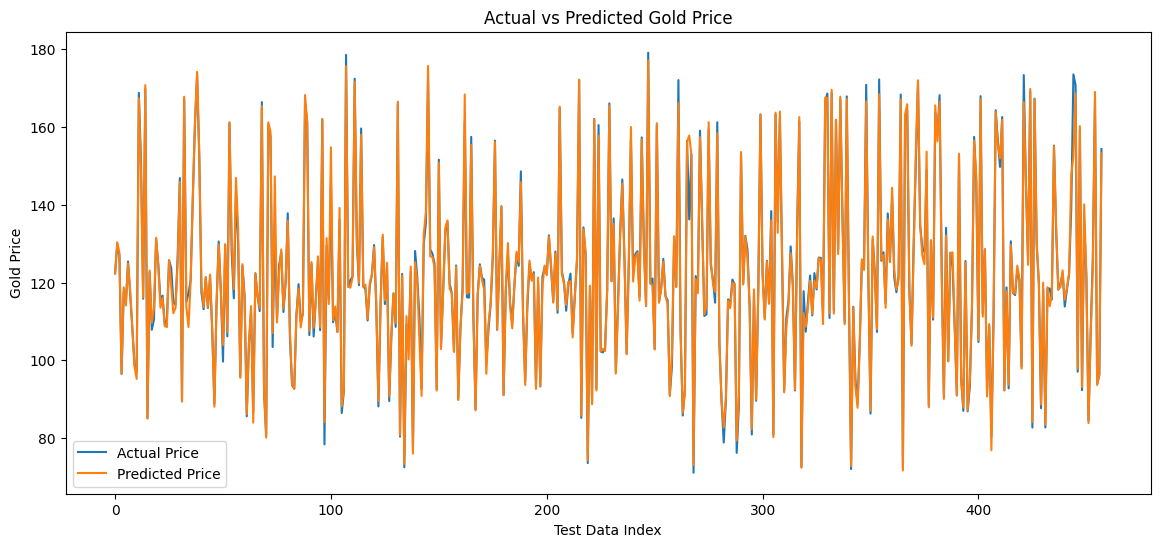

In [24]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")

plt.title("Actual vs Predicted Gold Price")
plt.xlabel("Test Data Index")
plt.ylabel("Gold Price")

plt.legend()
plt.show()

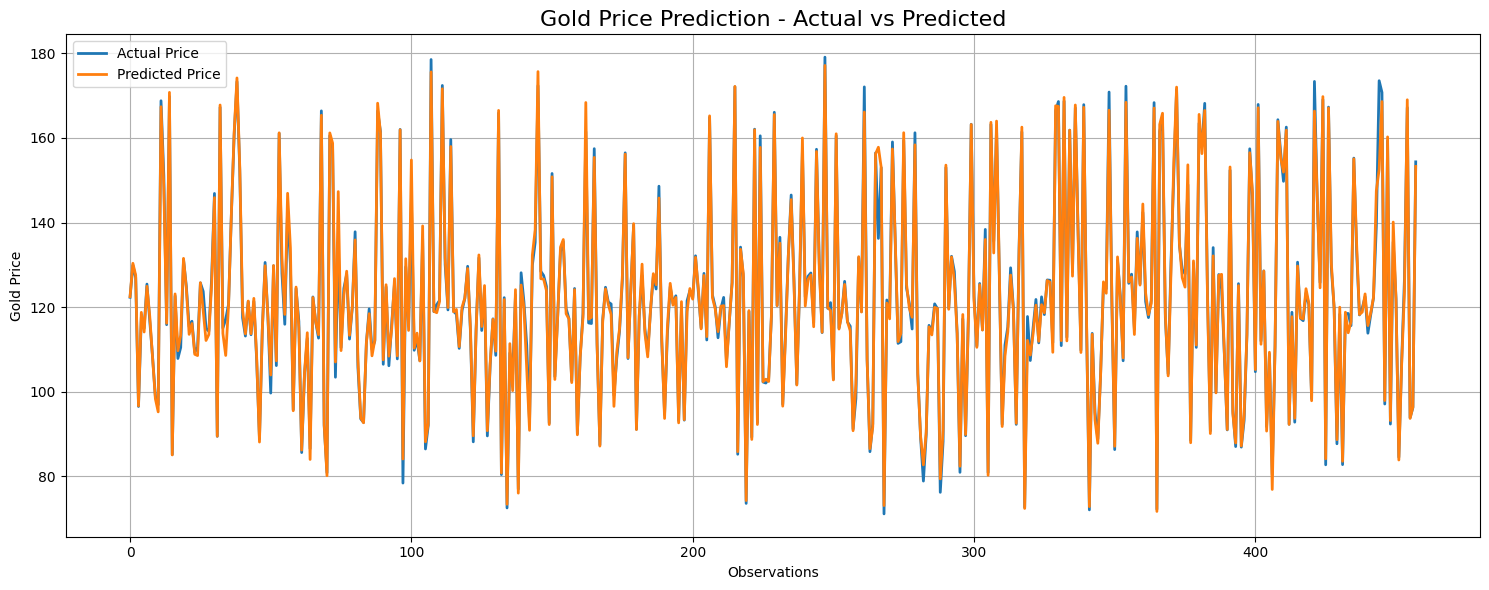

In [25]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values, linewidth=2)
plt.plot(y_pred, linewidth=2)

plt.title("Gold Price Prediction - Actual vs Predicted", fontsize=16)
plt.xlabel("Observations")
plt.ylabel("Gold Price")

plt.legend(["Actual Price", "Predicted Price"])
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
plt.savefig("gold_price_actual_vs_predicted.png", dpi=500, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

In [27]:
df["MA_10"] = df["GLD"].rolling(10).mean()
df["MA_30"] = df["GLD"].rolling(30).mean()

In [28]:
scaler = StandardScaler()
X = df[["MA_10", "MA_30"]]
y = df["GLD"]

In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mae,mse,rmse)

1.2348532216593915 5.115029665316735 2.2616431339441543


In [30]:
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5,10,None]
}
grid = GridSearchCV(RandomForestRegressor(), params, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [32]:
scores = cross_val_score(best_model, X, y, cv=5)
print(scores.mean())

0.5024069324927698
